In [70]:
import pandas as pd
import matplotlib.pyplot as plt

import datetime as dt

pd.set_option('display.max_rows', None)

In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "2019-Oct.csv"

# Loading dataset with pandas kwargs
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 20_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_66296/4272977193.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [2]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
5,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.619995,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.959991,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.160000,550978835,6280d577-25c8-4147-99a7-abc6048498d6
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.709999,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb


In [118]:
df['event_time'].max()

'2019-10-01 02:54:01 UTC'

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   event_time     20000 non-null  object  
 1   event_type     20000 non-null  category
 2   product_id     20000 non-null  int32   
 3   category_id    20000 non-null  int64   
 4   category_code  13412 non-null  category
 5   brand          17185 non-null  category
 6   price          20000 non-null  float32 
 7   user_id        20000 non-null  int32   
 8   user_session   20000 non-null  object  
dtypes: category(3), float32(1), int32(2), int64(1), object(2)
memory usage: 826.0+ KB


In [6]:
shape_df = df.shape

In [7]:
df.isnull().sum()/shape_df[0]

event_time       0.00000
event_type       0.00000
product_id       0.00000
category_id      0.00000
category_code    0.32940
brand            0.14075
price            0.00000
user_id          0.00000
user_session     0.00000
dtype: float64

In [8]:
df['product_id'].nunique()

7178

In [9]:
df['event_type'].nunique()

3

In [ ]:
df['event_type'].value_counts(normalize = True)

event_type
view        0.9774
purchase    0.0129
cart        0.0097
Name: proportion, dtype: float64

In [10]:
df.groupby(df['user_id'])['product_id'].count()

user_id
306441847    1
372944259    2
400972610    5
428099415    3
434894256    2
            ..
555467129    2
555467157    1
555467172    1
555467188    1
555467192    1
Name: product_id, Length: 5012, dtype: int64

In [11]:
df['user_id'].nunique()

5012

<Axes: >

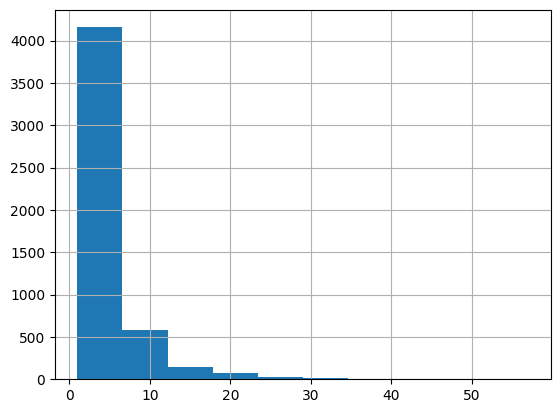

In [12]:
df.groupby(df['user_id'])['user_session'].count().hist()

In [13]:
df['user_session'].nunique()

5669

In [37]:
df['product_id'].nunique()

7178

In [ ]:
df['user_id'].nunique()

5012

In [ ]:
df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


/tmp/ipykernel_8805/2700003842.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


In [ ]:
df_phone = df[df['category_code']=='electronics.smartphone']

In [23]:
df_phone.shape

(5387, 9)

In [24]:
df_phone['event_type'].value_counts(normalize = True)

event_type
view        0.950065
cart        0.027102
purchase    0.022833
Name: proportion, dtype: float64

In [42]:
df_na = df[df['category_code'].isna()==True]

In [43]:
df_na.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.959991,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.160000,550978835,6280d577-25c8-4147-99a7-abc6048498d6
13,2019-10-01 00:00:15 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
15,2019-10-01 00:00:17 UTC,view,23100006,2053013561638126333,NaN,NaN,357.790009,513642368,17566c27-0a8f-4506-9f30-c6a2ccbf583b


In [51]:
df_na.shape

(6588, 9)

In [46]:
df_na['event_type'].value_counts()


event_type
view        6511
purchase      58
cart          19
Name: count, dtype: int64

In [4]:
list_category_code = ['electronics.smartphone',
'electronics.audio.headphone',
'electronics.clocks',
'computers.notebook',
'electronics.video.tv'
]


In [5]:
df['category_code'].value_counts()

category_code
electronics.smartphone                    5387
electronics.clocks                         664
computers.notebook                         633
electronics.audio.headphone                437
appliances.kitchen.refrigerators           390
appliances.environment.vacuum              321
electronics.video.tv                       297
auto.accessories.player                    294
appliances.environment.air_heater          267
apparel.shoes                              266
appliances.kitchen.washer                  263
apparel.shoes.keds                         206
electronics.telephone                      200
appliances.kitchen.meat_grinder            162
auto.accessories.alarm                     156
furniture.living_room.cabinet              148
furniture.living_room.sofa                 146
computers.desktop                          131
furniture.bedroom.bed                      121
accessories.bag                            117
appliances.kitchen.blender                 117

In [71]:
df.shape

(20000, 9)

In [18]:
df['category_code'].isin(list_category_code).sum()

np.int64(5387)

In [6]:
df_elec=df[df['category_code'].isin(list_category_code)]

In [7]:
df_elec.shape

(7418, 9)

In [8]:
df_elec['category_code'].nunique()

5

In [7]:
df_elec['date'] = df_elec['event_time'].apply(lambda s : str(s)[0:10])

/tmp/ipykernel_2768/1338302109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['date'] = df_elec['event_time'].apply(lambda s : str(s)[0:10])


In [8]:
df_elec['hour'] = df_elec['event_time'].apply(lambda s : str(s)[10:19])

/tmp/ipykernel_2768/507844041.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['hour'] = df_elec['event_time'].apply(lambda s : str(s)[10:19])


In [62]:
df_elec.shape

(5387, 11)

In [63]:
df_elec.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,hour
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,00:00:04
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,2019-10-01,00:00:11
11,2019-10-01 00:00:11 UTC,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,2019-10-01,00:00:11
19,2019-10-01 00:00:19 UTC,view,1005135,2053013555631882655,electronics.smartphone,apple,1747.790039,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,00:00:19
20,2019-10-01 00:00:20 UTC,view,1003306,2053013555631882655,electronics.smartphone,apple,588.770020,555446831,6ec635da-ea15-4a5d-96b4-c8ca9d38f89f,2019-10-01,00:00:20


In [ ]:

df_elec['date'] = pd.to_datetime(df_elec['date'])

/tmp/ipykernel_2768/2743374563.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['date'] = pd.to_datetime(df_elec['date'])


In [ ]:
df_elec['week_of_day'] = df_elec['date'].dt.day_name()

/tmp/ipykernel_33673/3461437742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['week_of_day'] = df_elec['date'].dt.day_name()


In [ ]:
df_elec.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,hour,week_of_day
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,00:00:04,Tuesday
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,2019-10-01,00:00:11,Tuesday
11,2019-10-01 00:00:11 UTC,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,2019-10-01,00:00:11,Tuesday
19,2019-10-01 00:00:19 UTC,view,1005135,2053013555631882655,electronics.smartphone,apple,1747.790039,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,00:00:19,Tuesday
20,2019-10-01 00:00:20 UTC,view,1003306,2053013555631882655,electronics.smartphone,apple,588.770020,555446831,6ec635da-ea15-4a5d-96b4-c8ca9d38f89f,2019-10-01,00:00:20,Tuesday


<Axes: >

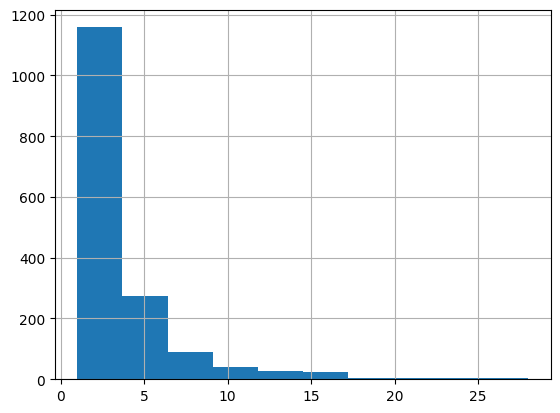

In [ ]:
df_elec.groupby('user_id')['event_type'].count().hist()

In [84]:
df_aux = df_elec[df_elec['event_type']=='view']

In [93]:
df_aux.groupby('user_id').count().mean()

event_time       3.141805
event_type       3.141805
product_id       3.141805
category_id      3.141805
category_code    3.141805
brand            3.138122
price            3.141805
user_session     3.141805
date             3.141805
hour             3.141805
week_of_day      3.141805
dtype: float64

In [91]:
df_aux.groupby('user_id').count().max()

event_time       28
event_type       28
product_id       28
category_id      28
category_code    28
brand            28
price            28
user_session     28
date             28
hour             28
week_of_day      28
dtype: int64

In [92]:
df_aux.groupby('user_id').count().std()

event_time       3.442066
event_type       3.442066
product_id       3.442066
category_id      3.442066
category_code    3.442066
brand            3.439538
price            3.442066
user_session     3.442066
date             3.442066
hour             3.442066
week_of_day      3.442066
dtype: float64

In [ ]:
df_aux.groupby('user_session').count().std()

In [24]:
df_elec = df_elec.sort_values(by = ['user_id', 'user_session','event_time'])
df_elec.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
14980,2019-10-01 02:45:58 UTC,view,1307073,2053013558920217191,computers.notebook,acer,669.000000,434894256,20a5a6bc-23ff-43d4-bc15-6bdb53c71edf
16744,2019-10-01 02:48:58 UTC,view,21404902,2053013561579406073,electronics.clocks,NaN,133.850006,443779465,66d261d9-6a81-45f6-afcc-054a7309259b
14918,2019-10-01 02:45:49 UTC,view,1005100,2053013555631882655,electronics.smartphone,samsung,154.419998,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7
16180,2019-10-01 02:48:02 UTC,view,1004750,2053013555631882655,electronics.smartphone,samsung,197.429993,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba
1097,2019-10-01 01:06:56 UTC,view,1004839,2053013555631882655,electronics.smartphone,oppo,179.389999,477121012,413b498a-71d5-49fa-b896-1761ab981917
1720,2019-10-01 02:19:51 UTC,view,5100798,2053013553341792533,electronics.clocks,garmin,2160.919922,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f
1942,2019-10-01 02:20:40 UTC,view,5100798,2053013553341792533,electronics.clocks,garmin,2160.919922,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f
2866,2019-10-01 02:23:15 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,464.130005,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f
2982,2019-10-01 02:23:34 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,464.130005,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f
3002,2019-10-01 02:23:39 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,464.130005,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f


In [ ]:
#df_elec['event_type_str'] = df_elec['event_type'].astype(str)
#df_events = df_elec.groupby(['user_id', 'user_session'])['event_type_str'].apply(lambda x: pd.Series([x.iloc[i] if i < len(x) else ' ' for i in range(11)
#               ], index=['event1', 'event2', 'event3','event4', 'event5', 'event6','event7', 'event8', 'event9','event10', 'event11' ])).reset_index()
#df_events.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_type_str')
#df_events.head(10)

In [9]:
df_elec['event_type_str'] = df_elec['event_type'].astype(str)
df_elec.sort_values(by=['user_id', 'user_session', 'product_id', 'event_time'])
df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


/tmp/ipykernel_66296/1888376266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_type_str'] = df_elec['event_type'].astype(str)
/tmp/ipykernel_66296/1888376266.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


In [47]:
df_events = df_elec.groupby(['user_id', 'user_session', 'product_id']).agg({
    'event_type_str' : " ".join,
    'event_time' : (lambda x : x.max() - x.min()),
}).reset_index()

In [11]:
df_events.head(10)

,user_id,user_session,product_id,event_type_str,event_time
0,434894256,20a5a6bc-23ff-43d4-bc15-6bdb53c71edf,1307073,view,0 days 00:00:00
1,443779465,66d261d9-6a81-45f6-afcc-054a7309259b,21404902,view,0 days 00:00:00
2,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00
3,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00
4,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00
5,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24
6,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,5100798,view view,0 days 00:00:49
7,489198768,f9b2142b-2bc7-42d4-8f72-7bd0552e8b53,4804056,view,0 days 00:00:00
8,489294047,0282c875-832f-49fb-888d-0094fad7990a,1004144,view,0 days 00:00:00
9,489294047,0282c875-832f-49fb-888d-0094fad7990a,1005008,view view view view view,0 days 00:01:39


In [12]:
df_events.describe()

,user_id,product_id,event_time
count,4.974000e+03,4.974000e+03,4974
mean,5.332911e+08,2.530483e+06,0 days 00:00:36.573984720
std,1.653757e+07,4.580535e+06,0 days 00:01:55.024092173
min,4.348943e+08,1.002098e+06,0 days 00:00:00
25%,5.166257e+08,1.004662e+06,0 days 00:00:00
50%,5.325132e+08,1.004903e+06,0 days 00:00:00
75%,5.501073e+08,1.306658e+06,0 days 00:00:24
max,5.554672e+08,2.141131e+07,0 days 00:30:40


In [48]:
df_events = df_events.rename(columns={'event_time':'duration'})

In [14]:
df_events['event_type_str'].value_counts()/df_events.shape[0]


event_type_str
view                                                           0.689988
view view                                                      0.201649
view view view                                                 0.044833
view view view view                                            0.014274
view view view view view                                       0.005629
view purchase view                                             0.005227
view cart purchase view                                        0.003217
view purchase                                                  0.003217
view cart                                                      0.003016
view cart purchase                                             0.002815
view cart view                                                 0.002211
view view view view view view                                  0.001608
view view purchase                                             0.001608
view purchase view view                          

In [33]:
df_events.shape

(4974, 5)

In [49]:
df_events['y']=df_events['event_type_str'].str.contains("purchase").apply(lambda x : int(x))

In [50]:
df_events.head(10)

,user_id,user_session,product_id,event_type_str,duration,y
0,434894256,20a5a6bc-23ff-43d4-bc15-6bdb53c71edf,1307073,view,0 days 00:00:00,0
1,443779465,66d261d9-6a81-45f6-afcc-054a7309259b,21404902,view,0 days 00:00:00,0
2,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00,0
3,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00,0
4,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00,0
5,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,0
6,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,5100798,view view,0 days 00:00:49,0
7,489198768,f9b2142b-2bc7-42d4-8f72-7bd0552e8b53,4804056,view,0 days 00:00:00,0
8,489294047,0282c875-832f-49fb-888d-0094fad7990a,1004144,view,0 days 00:00:00,0
9,489294047,0282c875-832f-49fb-888d-0094fad7990a,1005008,view view view view view,0 days 00:01:39,0


In [17]:
df_events['y'].value_counts()

y
0    4831
1     143
Name: count, dtype: int64

In [51]:
df_events['event_len'] = df_events['event_type_str'].apply(lambda x : len(x.split()))

In [52]:
df_events.head(10)

,user_id,user_session,product_id,event_type_str,duration,y,event_len
0,434894256,20a5a6bc-23ff-43d4-bc15-6bdb53c71edf,1307073,view,0 days 00:00:00,0,1
1,443779465,66d261d9-6a81-45f6-afcc-054a7309259b,21404902,view,0 days 00:00:00,0,1
2,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00,0,1
3,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00,0,1
4,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00,0,1
5,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,0,3
6,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,5100798,view view,0 days 00:00:49,0,2
7,489198768,f9b2142b-2bc7-42d4-8f72-7bd0552e8b53,4804056,view,0 days 00:00:00,0,1
8,489294047,0282c875-832f-49fb-888d-0094fad7990a,1004144,view,0 days 00:00:00,0,1
9,489294047,0282c875-832f-49fb-888d-0094fad7990a,1005008,view view view view view,0 days 00:01:39,0,5


In [42]:
df_events.describe()

,user_id,product_id,duration,y,event_len
count,4.974000e+03,4.974000e+03,4974,4974.000000,4974.000000
mean,5.332911e+08,2.530483e+06,0 days 00:00:36.573984720,0.028749,1.491355
std,1.653757e+07,4.580535e+06,0 days 00:01:55.024092173,0.167118,0.951797
min,4.348943e+08,1.002098e+06,0 days 00:00:00,0.000000,1.000000
25%,5.166257e+08,1.004662e+06,0 days 00:00:00,0.000000,1.000000
50%,5.325132e+08,1.004903e+06,0 days 00:00:00,0.000000,1.000000
75%,5.501073e+08,1.306658e+06,0 days 00:00:24,0.000000,2.000000
max,5.554672e+08,2.141131e+07,0 days 00:30:40,1.000000,12.000000


In [43]:
df_events.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4974 entries, 0 to 4973
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   user_id         4974 non-null   int32          
 1   user_session    4974 non-null   object         
 2   product_id      4974 non-null   int32          
 3   event_type_str  4974 non-null   object         
 4   duration        4974 non-null   timedelta64[ns]
 5   y               4974 non-null   int64          
 6   event_len       4974 non-null   int64          
dtypes: int32(2), int64(2), object(2), timedelta64[ns](1)
memory usage: 233.3+ KB


In [53]:
df_events['duration_mean']=df_events['duration']/df_events['event_len']

In [45]:
df_events.head(10)

,user_id,user_session,product_id,event_type_str,duration,y,event_len,duration_mean
0,434894256,20a5a6bc-23ff-43d4-bc15-6bdb53c71edf,1307073,view,0 days 00:00:00,0,1,0 days 00:00:00
1,443779465,66d261d9-6a81-45f6-afcc-054a7309259b,21404902,view,0 days 00:00:00,0,1,0 days 00:00:00
2,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00,0,1,0 days 00:00:00
3,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00,0,1,0 days 00:00:00
4,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00,0,1,0 days 00:00:00
5,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,0,3,0 days 00:00:08
6,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,5100798,view view,0 days 00:00:49,0,2,0 days 00:00:24.500000
7,489198768,f9b2142b-2bc7-42d4-8f72-7bd0552e8b53,4804056,view,0 days 00:00:00,0,1,0 days 00:00:00
8,489294047,0282c875-832f-49fb-888d-0094fad7990a,1004144,view,0 days 00:00:00,0,1,0 days 00:00:00
9,489294047,0282c875-832f-49fb-888d-0094fad7990a,1005008,view view view view view,0 days 00:01:39,0,5,0 days 00:00:19.800000


,y,event_len
0,0,"Axes(0.125,0.11;0.775x0.77)"
1,1,"Axes(0.125,0.11;0.775x0.77)"


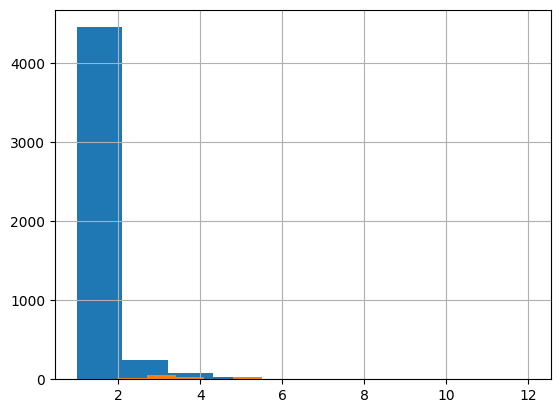

In [46]:
df_events.groupby(df_events['y'], as_index=False)['event_len'].hist()

In [47]:
df_events['event_len'].describe()

count    4974.000000
mean        1.491355
std         0.951797
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        12.000000
Name: event_len, dtype: float64

In [54]:
df_event_feature = pd.merge(df_events,df_elec.drop(columns=['event_type_str']), on=['user_id', 'user_session', 'product_id'], how='left')

In [55]:
df_event_feature.head(10)

,user_id,user_session,product_id,event_type_str,duration,y,event_len,duration_mean,event_time,event_type,category_id,category_code,brand,price
0,434894256,20a5a6bc-23ff-43d4-bc15-6bdb53c71edf,1307073,view,0 days 00:00:00,0,1,0 days 00:00:00,2019-10-01 02:45:58+00:00,view,2053013558920217191,computers.notebook,acer,669.000000
1,443779465,66d261d9-6a81-45f6-afcc-054a7309259b,21404902,view,0 days 00:00:00,0,1,0 days 00:00:00,2019-10-01 02:48:58+00:00,view,2053013561579406073,electronics.clocks,NaN,133.850006
2,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00,0,1,0 days 00:00:00,2019-10-01 02:45:49+00:00,view,2053013555631882655,electronics.smartphone,samsung,154.419998
3,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00,0,1,0 days 00:00:00,2019-10-01 02:48:02+00:00,view,2053013555631882655,electronics.smartphone,samsung,197.429993
4,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00,0,1,0 days 00:00:00,2019-10-01 01:06:56+00:00,view,2053013555631882655,electronics.smartphone,oppo,179.389999
5,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,0,3,0 days 00:00:08,2019-10-01 02:23:15+00:00,view,2053013555631882655,electronics.smartphone,apple,464.130005
6,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,0,3,0 days 00:00:08,2019-10-01 02:23:34+00:00,view,2053013555631882655,electronics.smartphone,apple,464.130005
7,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,0,3,0 days 00:00:08,2019-10-01 02:23:39+00:00,view,2053013555631882655,electronics.smartphone,apple,464.130005
8,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,5100798,view view,0 days 00:00:49,0,2,0 days 00:00:24.500000,2019-10-01 02:19:51+00:00,view,2053013553341792533,electronics.clocks,garmin,2160.919922
9,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,5100798,view view,0 days 00:00:49,0,2,0 days 00:00:24.500000,2019-10-01 02:20:40+00:00,view,2053013553341792533,electronics.clocks,garmin,2160.919922


In [56]:
y = pd.DataFrame(df_event_feature['y'])

In [57]:
y.head(10)

,y
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [58]:
X = pd.DataFrame(df_event_feature.drop(columns=['y']))

In [59]:
X.head(10)

,user_id,user_session,product_id,event_type_str,duration,event_len,duration_mean,event_time,event_type,category_id,category_code,brand,price
0,434894256,20a5a6bc-23ff-43d4-bc15-6bdb53c71edf,1307073,view,0 days 00:00:00,1,0 days 00:00:00,2019-10-01 02:45:58+00:00,view,2053013558920217191,computers.notebook,acer,669.000000
1,443779465,66d261d9-6a81-45f6-afcc-054a7309259b,21404902,view,0 days 00:00:00,1,0 days 00:00:00,2019-10-01 02:48:58+00:00,view,2053013561579406073,electronics.clocks,NaN,133.850006
2,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00,1,0 days 00:00:00,2019-10-01 02:45:49+00:00,view,2053013555631882655,electronics.smartphone,samsung,154.419998
3,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00,1,0 days 00:00:00,2019-10-01 02:48:02+00:00,view,2053013555631882655,electronics.smartphone,samsung,197.429993
4,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00,1,0 days 00:00:00,2019-10-01 01:06:56+00:00,view,2053013555631882655,electronics.smartphone,oppo,179.389999
5,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,3,0 days 00:00:08,2019-10-01 02:23:15+00:00,view,2053013555631882655,electronics.smartphone,apple,464.130005
6,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,3,0 days 00:00:08,2019-10-01 02:23:34+00:00,view,2053013555631882655,electronics.smartphone,apple,464.130005
7,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,3,0 days 00:00:08,2019-10-01 02:23:39+00:00,view,2053013555631882655,electronics.smartphone,apple,464.130005
8,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,5100798,view view,0 days 00:00:49,2,0 days 00:00:24.500000,2019-10-01 02:19:51+00:00,view,2053013553341792533,electronics.clocks,garmin,2160.919922
9,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,5100798,view view,0 days 00:00:49,2,0 days 00:00:24.500000,2019-10-01 02:20:40+00:00,view,2053013553341792533,electronics.clocks,garmin,2160.919922


In [42]:
X.shape

(5387, 13)

In [45]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7418 entries, 0 to 7417
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   user_id         7418 non-null   int32              
 1   user_session    7418 non-null   object             
 2   product_id      7418 non-null   int32              
 3   event_type_str  7418 non-null   object             
 4   duration        7418 non-null   timedelta64[ns]    
 5   event_time      7418 non-null   datetime64[ns, UTC]
 6   event_type      7418 non-null   category           
 7   category_id     7418 non-null   int64              
 8   category_code   7418 non-null   category           
 9   brand           7291 non-null   category           
 10  price           7418 non-null   float32            
dtypes: category(3), datetime64[ns, UTC](1), float32(1), int32(2), int64(1), object(2), timedelta64[ns](1)
memory usage: 450.4+ KB


<Axes: >

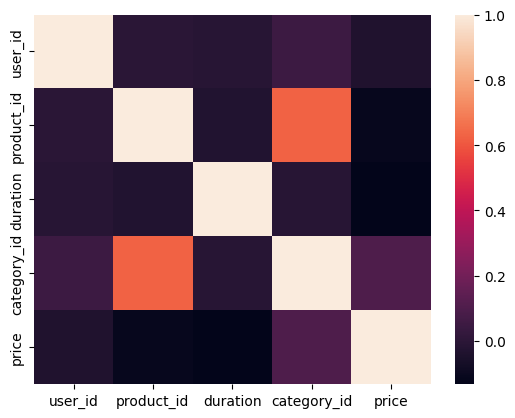

In [24]:
import numpy as np
import seaborn as sns

sns.heatmap(X.select_dtypes(include=np.number).corr())

In [58]:
X['brand'].value_counts()

brand
samsung             1995
apple               1890
xiaomi              1086
huawei               545
acer                 175
oppo                 162
lenovo               161
casio                128
hp                   124
vivo                 110
asus                  82
sony                  73
meizu                 64
nokia                 63
lg                    59
elari                 50
artel                 41
garmin                39
oneplus               33
jbl                   31
honor                 25
dell                  25
tissot                24
msi                   18
bq                    17
orient                16
swatch                15
longines              15
haier                 15
aimoto                13
armani                12
wonlex                11
yasin                 11
kivi                  10
tp-link               10
pioneer                9
doogee                 7
ritmix                 6
tcl                    6
marshall           

In [60]:
X = X.rename(columns={'event_type_str':'sequence_event', 'event_len':'sequence_len'})

In [61]:
X.head(5)

,user_id,user_session,product_id,sequence_event,duration,sequence_len,duration_mean,event_time,event_type,category_id,category_code,brand,price
0,434894256,20a5a6bc-23ff-43d4-bc15-6bdb53c71edf,1307073,view,0 days,1,0 days,2019-10-01 02:45:58+00:00,view,2053013558920217191,computers.notebook,acer,669.000000
1,443779465,66d261d9-6a81-45f6-afcc-054a7309259b,21404902,view,0 days,1,0 days,2019-10-01 02:48:58+00:00,view,2053013561579406073,electronics.clocks,NaN,133.850006
2,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days,1,0 days,2019-10-01 02:45:49+00:00,view,2053013555631882655,electronics.smartphone,samsung,154.419998
3,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days,1,0 days,2019-10-01 02:48:02+00:00,view,2053013555631882655,electronics.smartphone,samsung,197.429993
4,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days,1,0 days,2019-10-01 01:06:56+00:00,view,2053013555631882655,electronics.smartphone,oppo,179.389999


In [30]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [62]:
encoder = OneHotEncoder(sparse_output=False,
                        drop='if_binary',
                        handle_unknown="ignore").set_output(transform="pandas")

X_encoder = encoder.fit_transform(X[['sequence_event', 'category_code']])


In [63]:
X_encoder.head(10)

,sequence_event_purchase view,sequence_event_view,sequence_event_view cart,sequence_event_view cart cart,sequence_event_view cart cart cart cart cart purchase view,sequence_event_view cart cart cart cart purchase view,sequence_event_view cart cart cart purchase,sequence_event_view cart cart cart view purchase,sequence_event_view cart cart purchase,sequence_event_view cart cart purchase view,...,sequence_event_view view view view view view view,sequence_event_view view view view view view view cart view,sequence_event_view view view view view view view view,sequence_event_view view view view view view view view view,sequence_event_view view view view view view view view view view view view,category_code_computers.notebook,category_code_electronics.audio.headphone,category_code_electronics.clocks,category_code_electronics.smartphone,category_code_electronics.video.tv
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [86]:
X_encoder.shape

(7418, 72)

In [66]:
X.dtypes

user_id                         int32
user_session                   object
product_id                      int32
sequence_event                 object
duration              timedelta64[ns]
sequence_len                    int64
duration_mean         timedelta64[ns]
event_time        datetime64[ns, UTC]
event_type                   category
category_id                     int64
category_code                category
brand                        category
price                         float32
dtype: object

In [73]:
X['duration_mean_sec'] = X['duration_mean'].dt.total_seconds()

In [76]:
X['duration_mean_sec'].describe()

count    7418.000000
mean       24.523996
std        47.881565
min         0.000000
25%         0.000000
50%         7.000000
75%        29.333333
max       871.000000
Name: duration_mean_sec, dtype: float64

In [80]:
rb_scaler = RobustScaler().set_output(transform = "pandas")

X_scaled = rb_scaler.fit_transform(X[[ 'sequence_len', 'price', 'duration_mean_sec']])

In [85]:
X_scaled.shape

(7418, 3)

In [91]:
X_preprocessed = pd.concat([X_encoder, X_scaled],axis=1)

In [92]:
X_preprocessed.head(10)

,sequence_event_purchase view,sequence_event_view,sequence_event_view cart,sequence_event_view cart cart,sequence_event_view cart cart cart cart cart purchase view,sequence_event_view cart cart cart cart purchase view,sequence_event_view cart cart cart purchase,sequence_event_view cart cart cart view purchase,sequence_event_view cart cart purchase,sequence_event_view cart cart purchase view,...,sequence_event_view view view view view view view view view,sequence_event_view view view view view view view view view view view view,category_code_computers.notebook,category_code_electronics.audio.headphone,category_code_electronics.clocks,category_code_electronics.smartphone,category_code_electronics.video.tv,sequence_len,price,duration_mean_sec
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.5,0.764320,-0.238636
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.5,-0.302268,-0.238636
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.5,-0.261271,-0.238636
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.5,-0.175549,-0.238636
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.5,-0.211504,-0.238636
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.5,0.356001,0.034091
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.5,0.356001,0.034091
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.5,0.356001,0.034091
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.737812,0.596591
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.737812,0.596591


In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

log_reg = LogisticRegression(class_weight='balanced')
model = log_reg.fit(X_preprocessed, y)
cv_result = cross_validate(log_reg , X_preprocessed, y, cv = 5, scoring = ['precision', 'recall', 'f1'])

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/uti

In [99]:
cv_result.keys()

dict_keys(['fit_time', 'score_time', 'test_precision', 'test_recall', 'test_f1'])

In [100]:
cv_result['test_precision'].mean()

np.float64(0.8397093914814627)

In [101]:
cv_result['test_recall'].mean()

np.float64(1.0)

In [102]:
cv_result['test_f1'].mean()

np.float64(0.9103198467253213)

In [114]:
feature_names = list(X_preprocessed.columns)

In [115]:
feature_names

['sequence_event_purchase view',
 'sequence_event_view',
 'sequence_event_view cart',
 'sequence_event_view cart cart',
 'sequence_event_view cart cart cart cart cart purchase view',
 'sequence_event_view cart cart cart cart purchase view',
 'sequence_event_view cart cart cart purchase',
 'sequence_event_view cart cart cart view purchase',
 'sequence_event_view cart cart purchase',
 'sequence_event_view cart cart purchase view',
 'sequence_event_view cart cart view',
 'sequence_event_view cart cart view cart purchase',
 'sequence_event_view cart cart view purchase view',
 'sequence_event_view cart purchase',
 'sequence_event_view cart purchase purchase',
 'sequence_event_view cart purchase view',
 'sequence_event_view cart purchase view cart',
 'sequence_event_view cart purchase view cart purchase view',
 'sequence_event_view cart purchase view purchase',
 'sequence_event_view cart purchase view view',
 'sequence_event_view cart view',
 'sequence_event_view cart view cart',
 'sequence_

In [117]:
from sklearn.inspection import permutation_importance
r = permutation_importance(model, X_preprocessed, y,
                           n_repeats=30,
                           random_state=0)
for i in r.importances_mean.argsort()[::-1]:
    #if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
    print(f"{feature_names[i]:<8}"
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")

sequence_event_view0.230 +/- 0.004
sequence_event_view view0.187 +/- 0.003
sequence_event_view view view0.079 +/- 0.001
sequence_event_view view view view0.034 +/- 0.001
sequence_event_view view view view view0.019 +/- 0.001
sequence_event_view view view view view view0.007 +/- 0.000
sequence_event_view cart view0.004 +/- 0.000
sequence_event_view view view view view view view0.004 +/- 0.000
sequence_event_view cart0.004 +/- 0.000
sequence_event_view view view view view view view view0.003 +/- 0.000
sequence_event_view view cart view0.003 +/- 0.000
sequence_event_view purchase view0.003 +/- 0.000
category_code_electronics.video.tv0.002 +/- 0.000
sequence_event_view view cart0.002 +/- 0.000
sequence_event_view cart cart view0.002 +/- 0.000
sequence_event_view view view view view view view view view view view view0.002 +/- 0.000
category_code_electronics.smartphone0.002 +/- 0.000
sequence_event_view view view cart cart0.001 +/- 0.000
sequence_event_view view view view view view view cart

In [119]:
X_preprocessed.shape

(7418, 75)